In [1]:
import subprocess
import sys

COLAB = "google.colab" in sys.modules


def _install(package):
    if COLAB:
        ans = input(f"Install { package }? [y/n]:")
        if ans.lower() in ["y", "yes"]:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "--quiet", package]
            )
            print(f"{ package } installed!")


def _colab_install_missing_deps(deps):
    import importlib

    for dep in deps:
        if importlib.util.find_spec(dep) is None:
            if dep == "iris":
                dep = "scitools-iris"
            _install(dep)


deps = ["pyobis", "joblib"]
_colab_install_missing_deps(deps)

# ?

Created: 2026-07-xx

The `earthaccess` library requires a login to download access the data. Please navigate to https://earthaccess.readthedocs.io/en/latest/user/ and follow the instructions there on how to create one.

In [2]:
import earthaccess

auth = earthaccess.login(persist=True)

We can not define our search bounding box, time span, and filter for the 1 degree dataset only. This can be a lot of data so we will avoid the 4km high resolution for now.

In [3]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CHL",
    temporal=("2025-01-01", "2025-12-31"),
    bounding_box=(-90.0, 40.0, -75.0, 47.0),
)

fileset = earthaccess.open(results)
one_degree = [f for f in fileset if f.full_name.endswith("1deg.nc")]

We will re-download the data if we do not have it already. The local cache will save us some time and ensure we always have the data even if the server removes them.

In [4]:
from pathlib import Path
import xarray as xr


fname = "chlor_a.nc"

if not Path(fname).exists():
    def fake_time(ds):
        time = ds.attrs["product_name"].split(".")[1].split("_")
        time = pd.to_datetime(time).mean()
        ds = ds.assign_coords(time=time)
        return ds["chlor_a"].expand_dims(time=1)

    ds = xr.open_mfdataset(one_degree, preprocess=fake_time)
    chlor_a = ds["chlor_a"].where(
        (ds["chlor_a"] < ds["chlor_a"].display_max)
        & (ds["chlor_a"] > ds["chlor_a"].display_min)
    )

    chlor_a = chlor_a.mean(dim="time").compute()
else:
    chlor_a = xr.open_dataset(fname)


# Make a DataArray for the chlor_a variable only.
chlor_a = chlor_a["chlor_a"]

Now we can query the OBIS equivalent for phytoplankton (testing some generic groupings):

term | WoRMS | OBIS Map
-----|-------|---------
Diatoms (Bacillariophyceae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=148899 | https://mapper.obis.org/?taxonid=148899
Dinoflagellates (Dinophyceae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=19542 | https://mapper.obis.org/?taxonid=19542
Cyanobacteria (Blue-green algae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=146537 | https://mapper.obis.org/?taxonid=146537
Coccolithophyceae | https://www.marinespecies.org/aphia.php?p=taxdetails&id=592906 | https://mapper.obis.org/?taxonid=592906

In [5]:
from pyobis import occurrences


aphia_ids = ["148899", "19542", "146537", "592906"]

query = occurrences.search(taxonid=aphia_ids, size=100)
data = query.execute()

data

2026-07-27 13:48:26 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-07-27 13:48:26 - pyobis.obisutils - INFO - 100 to be fetched. Estimated time =0.0319719624519348160 seconds
2026-07-27 13:48:26 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 100/100
2026-07-27 13:48:26 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-07-27 13:48:26 - pyobis.obisutils - INFO - Fetched 100 records.


,basisOfRecord,bibliographicCitation,brackish,catalogNumber,class,classid,collectionCode,coordinateUncertaintyInMeters,country,date_end,...,fieldNotes,preparations,verbatimLocality,associatedOccurrences,eventType,identificationVerificationStatus,identificationQualifier,individualCount,forma,formaid
0,MaterialSample,"Brown, M. V. et al. Continental scale monitori...",True,102.100.100/35552-EF9455B8FFF22EFC18B3DCB74655...,Coccolithophyceae,592906.0,BioPlatforms Marine microbes NRS ROT,50.0,Australia,1.498349e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HumanObservation,Continuous Plankton Recorder (CPR) data from t...,True,23AC-43-172,Bacillariophyceae,148899.0,CPR,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MaterialSample,"Focardi, Amaranta,Ostrowski, Martin,Goossen, K...",True,102.100.100/35991-3012DC434CD10C331A5B06F1EAFB...,Dinophyceae,19542.0,BioPlatforms Marine microbes in2016_v04,50.0,Australia,1.473984e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.676419e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.447891e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Occurrence,NaN,True,d2ec2d5e06a7683d488c60683531_ARVAM_60683531_AR...,Dinophyceae,19542.0,QUADRIGE - Coastal monitoring database and pro...,NaN,NaN,1.521072e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.558138e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,MATERIAL_SAMPLE,NaN,True,NaN,Cyanophyceae,146542.0,NaN,NaN,NaN,1.475712e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,MaterialSample,"Brown, M. V. et al. Continental scale monitori...",True,102.100.100/34175-9BDF23CB027253367726EAD57B18...,Coccolithophyceae,592906.0,BioPlatforms Marine microbes NRS ROT,50.0,Australia,1.458691e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The next step is top query for gridded occurrence data for the `aphia_ids` we selected above.

In [6]:
features = occurrences.grid(3, taxonid=aphia_ids).execute()

2026-07-27 13:48:28 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-07-27 13:48:28 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis


And convert to geodataframe to visualize and match with the PACE data later.

In [7]:
import geopandas as gpd


gdf = gpd.GeoDataFrame.from_features(features)
gdf

,geometry,n
0,"POLYGON ((150.46875 -35.15625, 151.875 -35.156...",1517518
1,"POLYGON ((153.28125 -28.125, 154.6875 -28.125,...",1090663
2,"POLYGON ((147.65625 -43.59375, 149.0625 -43.59...",980357
3,"POLYGON ((115.3125 -32.34375, 116.71875 -32.34...",911509
4,"POLYGON ((146.25 -19.6875, 147.65625 -19.6875,...",831334
...,...,...
8077,"POLYGON ((-150.46875 -70.3125, -149.0625 -70.3...",1
8078,"POLYGON ((-146.25 -87.1875, -144.84375 -87.187...",1
8079,"POLYGON ((-167.34375 -78.75, -165.9375 -78.75,...",1
8080,"POLYGON ((-178.59375 -73.125, -177.1875 -73.12...",1


Note that the occurence rages from 1 to large numbers (`~10e6`). We need to log-normalize the colors for better visualization. After that, we can plot the two side.

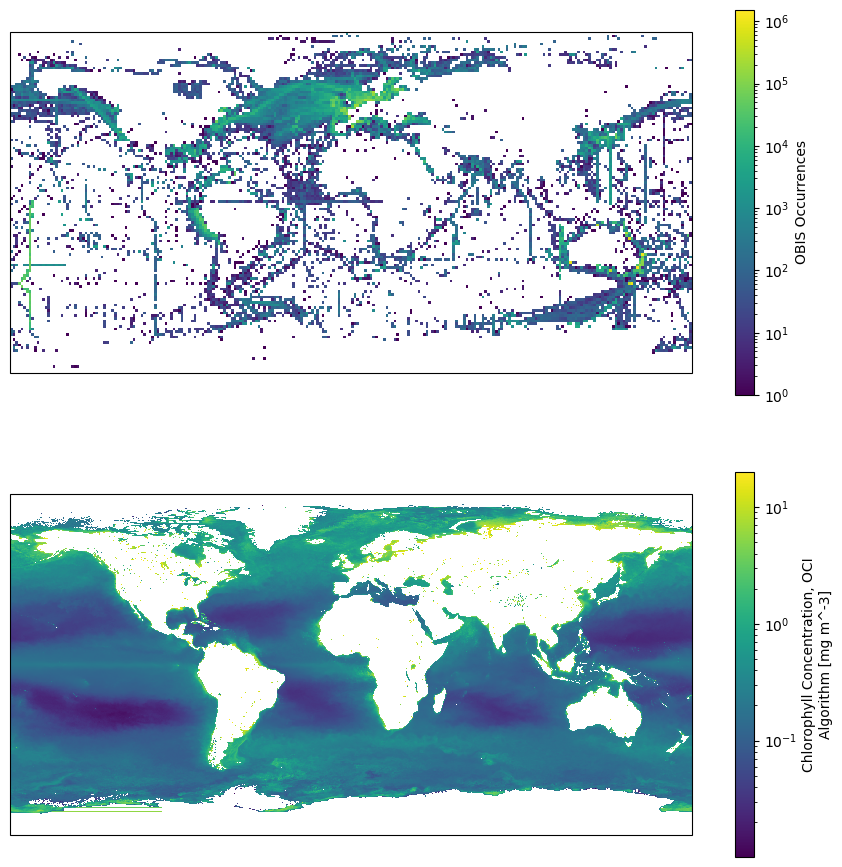

In [8]:
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.pyplot as plt


norm = colors.LogNorm()

projection = ccrs.PlateCarree()
fig, (ax0, ax1) = plt.subplots(
    nrows=2,
    subplot_kw={"projection": projection},
    sharex=True,
    sharey=True,
    figsize=(11, 11)
)

ax = gdf.plot(
    column="n",
    norm=colors.LogNorm(),
    legend=True,
    legend_kwds={"label": "OBIS Occurrences"},
    ax=ax0,
)


cs = chlor_a.plot(norm=colors.LogNorm(), ax=ax1)

We can see some features, like a higher density near the coast, currents, and the oligotrophic areas at the gyres centers. As expected, OBIS data density falls off quickly outside of the North Atlantic.

In order to test a better "qualitative" way to compare the data we will average out the PACE data to the OBIS occurrences geometry, and put the data on an hexagonal hierarchical geospatial indexing system (H3) for plotting and comparing each hexagon.

In [9]:
def average_chlor_a(geom):
    xmin, ymin, xmax, ymax = geom

    c = chlor_a.where(
        (xmin <= chlor_a["lon"])
        & (chlor_a["lon"] <= xmax)
        & (ymin <= chlor_a["lat"])
        & (chlor_a["lat"] <= ymax),
        drop=True,
    )
    return float(c.mean().to_numpy())

We will use joblib's `Parallel` to speed up the averaves.

In [10]:
import multiprocessing
from joblib import Parallel, delayed


num_cores = multiprocessing.cpu_count()

bounds = gdf["geometry"].bounds.to_numpy()

chlor_avg = Parallel(n_jobs=num_cores)(
    delayed(average_chlor_a)(geom) for geom in bounds
)

gdf["chlor_avg"] = chlor_avg

Now make the H3 index for both datasets.

In [11]:
import h3pandas


gdf["x"] = gdf["geometry"].centroid.x
gdf["y"] = gdf["geometry"].centroid.y

# The resolution goes from 0-15, using 2 b/c that is the closest to the OBIS squares.
resolution = 2

df = gdf[["x", "y", "n", "chlor_avg"]]

dfh3 = df.h3.geo_to_h3(
    resolution=resolution,
    lat_col="y",
    lng_col="x",
    set_index=True,
)


dfh3 = dfh3.drop(columns=["x", "y"]).groupby(dfh3.index.name).sum()
gdfh3 = dfh3.h3.h3_to_geo_boundary()

We need to correct the longitudes for better plotting at the dateline.

In [12]:
import numpy as np


def fix_geom(geom):
    from shapely import Polygon

    lons, lats = map(list, geom.boundary.coords.xy)
    if max(abs(np.diff(lons))) > 180:
        xx = [x + 360 if x < 0 else x for x in lons]
        return Polygon(zip(xx, lats))
    else:
        return geom


gdfh3["geometry"] = gdfh3["geometry"].apply(fix_geom)
gdfh3["log_n"] = np.log(gdfh3["n"])

Last but not least, to make it easier to spot patterns, let's make all the data between 0-1 so we can easily see any patterns that matches on both sources.

In [13]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())


gdfh3["n_norm"] = normalize(gdfh3["n"])
gdfh3["chlor_norm"] = normalize(gdfh3["chlor_avg"])

The obis data at the top and pace at the lower panel.

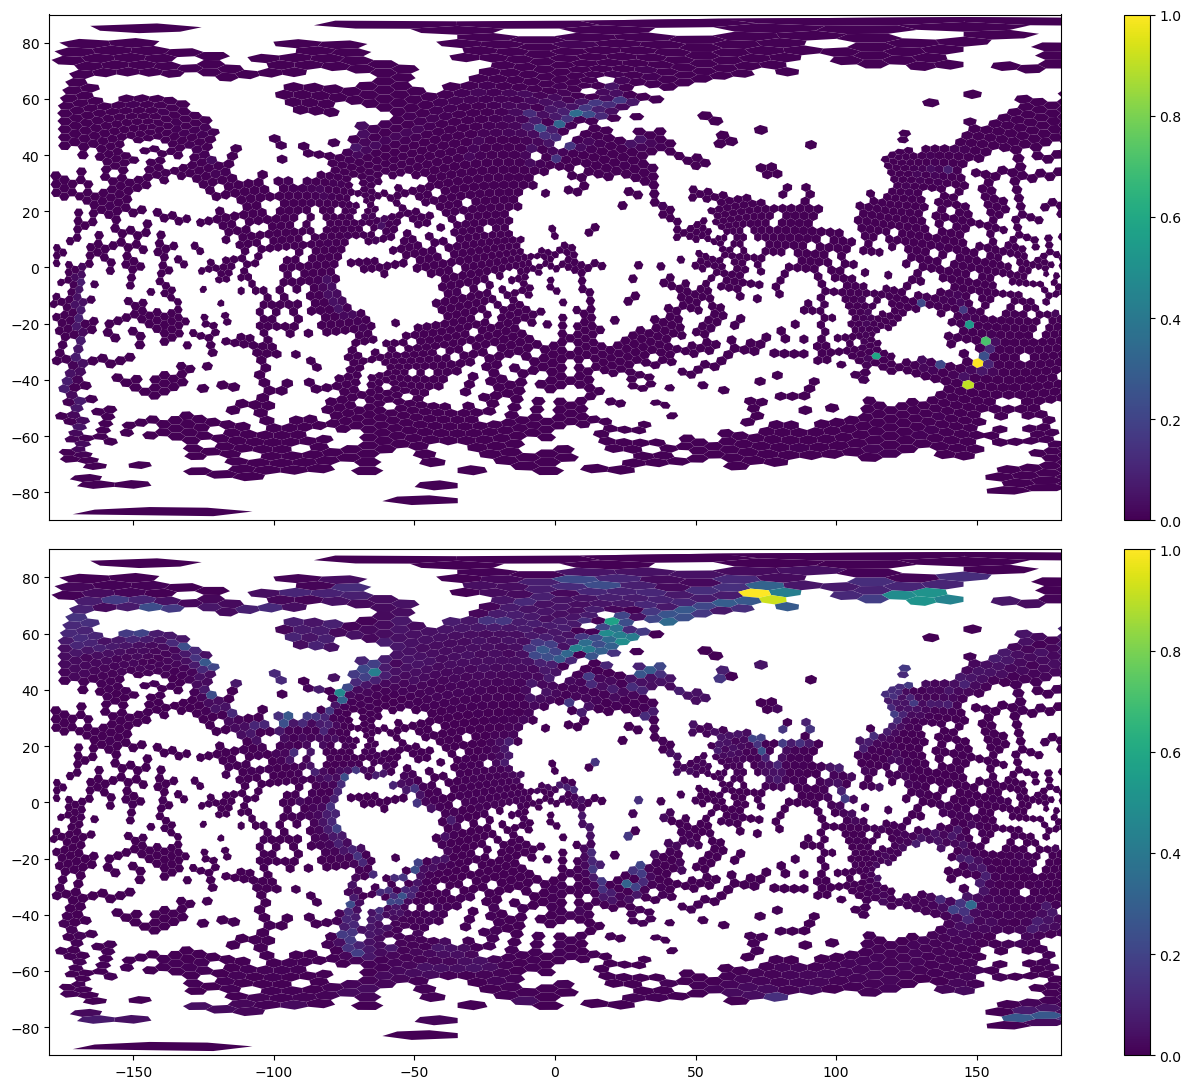

In [14]:
fig, (ax0, ax1) = plt.subplots(nrows=2, figsize=(13, 11), sharex=True, sharey=True)

ax = gdfh3.plot(column="n_norm", ax=ax0, legend=True)
gdfh3.plot(column="chlor_norm", ax=ax1, legend=True)
ax0.axis([-180, 180, -90, 90])
fig.tight_layout()